In [1]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import itertools
import os
import random
from tqdm import tqdm
import multiprocessing
from rdkit import Chem

sys.path.append("/home/iscb/wolfson/hagairavid/ligand_aligner")

BIO_LIP_COLUMNS = [
"PDB ID",
"Receptor chain",
"Resolution. '-1.00' stands for lack of resolution information, e.g. for NMR",
"Binding site number code",
"Ligand_ID",
"Ligand_chain",
"Ligand serial number",
"    Binding site residues (with PDB residue numbering)",
"    Binding site residues (with residue re-numbered starting from 1)",
"Catalytic site residues (different sites are separated by ';') (with PDB residue numbering)",
"    Catalytic site residues (different sites are separated by ';') (with residue re-numbered starting from 1)",
"EC number",
"GO terms",
"Binding affinity by manual survey of the original literature. The information in '()' is the PubMed ID",
"Binding affinity provided by the Binding MOAD database. The information in '()' is the ligand information in Binding MOAD",
"Binding affinity provided by the PDBbind-CN database. The information in '()' is the ligand information in PDBbind-CN",
"Binding affinity provided by the BindingDB database",
"UniProt ID",
"PubMed ID",
"Residue sequence number of the ligand (field _atom_site.auth_seq_id in PDBx/mmCIF format)",
"Receptor sequence"]


In [2]:
# df = pd.read_csv('/home/iscb/wolfson/hagairavid/databases/BioLiP_nr_0102.txt', sep="\t", header=None, names=BIO_LIP_COLUMNS)
df = pd.read_csv('/home/iscb/wolfson/hagairavid/ligand_alligner/BioLiP_nr_10082025.txt', sep="\t", header=None, names=BIO_LIP_COLUMNS)
relevant_columns = ["PDB ID", "Receptor chain", "Ligand_ID", "Ligand_chain"]
df = df[relevant_columns].astype('str')

/tmp/ipykernel_1195042/1081665381.py:2: DtypeWarning: Columns (13,14,16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/home/iscb/wolfson/hagairavid/ligand_alligner/BioLiP_nr_10082025.txt', sep="\t", header=None, names=BIO_LIP_COLUMNS)


### Ligand metdata file
Contains information regard each ligand, including the SMILE structure that will be later use to count the number of atoms per ligand

In [3]:
tsv_file = 'ligand.tsv.gz'
# tsv_file = '/home/iscb/wolfson/hagairavid/ligand_alligner/ligand_nr.tar.bz2'
ligands_df = pd.read_csv(tsv_file, sep='\t', encoding='utf-8', on_bad_lines='skip')
ligands_df.set_index(ligands_df.columns[0], inplace=True)
ligands_df.to_csv('ligands.csv')

### Leave one ligand chain
Since the goal of this script is to find pairs of proteins that bind the same ligands, there is no need to treat 

In [4]:
# df = df[df["Ligand_chain"]=='A']
# df.shape

## Leave unique ligand chain per ligand

In [5]:
value_counts = df["Ligand_ID"].value_counts()
values_to_keep = value_counts[value_counts > 1].index
df = df[df["Ligand_ID"].isin(values_to_keep)]

filtered_df = df.groupby(["Ligand_ID", "PDB ID"]).apply(lambda x: x.loc[x['Receptor chain'].idxmin()])
filtered_df = df.groupby(["Ligand_ID", "PDB ID", "Receptor chain"]).apply(lambda x: x.loc[x['Ligand_chain'].idxmin()])

# remove dna, rna, peptide and none
print("Before filtering:", filtered_df.shape)
filtered_df = filtered_df[~filtered_df['Ligand_ID'].str.contains('DNA|RNA|PEPTIDE|NONE', case=False, na=False)]
print("After filtering:", filtered_df.shape)

filtered_df.shape


/tmp/ipykernel_1195042/1612362139.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  filtered_df = df.groupby(["Ligand_ID", "PDB ID"]).apply(lambda x: x.loc[x['Receptor chain'].idxmin()])


Before filtering: (54105, 4)
After filtering: (40846, 4)


/tmp/ipykernel_1195042/1612362139.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  filtered_df = df.groupby(["Ligand_ID", "PDB ID", "Receptor chain"]).apply(lambda x: x.loc[x['Ligand_chain'].idxmin()])


(40846, 4)

In [6]:
value_counts = df["Ligand_ID"].value_counts()
pairs_per_ligand = value_counts.apply(lambda x: x*(x-1)//2)
    
# Compute the total number of pairs
total_pairs = pairs_per_ligand.sum()
print("Total number of pairs:", total_pairs)

Total number of pairs: 159452011


In [7]:
def compute_heavy_atoms(smiles):
        smiles_list = smiles.split(';')
        heavy_atoms_counts = []
        for smi in smiles_list:
            if smi[-1] == ';':
                 smi = smi[:-1]
            mol = Chem.MolFromSmiles(smi.strip())  # Strip whitespace around each SMILES string
            if mol is not None:
                heavy_atoms_counts.append(mol.GetNumHeavyAtoms())
        return heavy_atoms_counts


### Counting number of atoms per ligand

In [8]:
ligand_to_n_atoms = {}
filtered_df['n_ligand_atoms'] = pd.NA
n_failed = 0
for i, ligand_id in tqdm(enumerate(filtered_df["Ligand_ID"].unique()), desc="Processing Ligand_IDs"):
    try:
        smiles = ligands_df.loc[ligand_id]['SMILES']
    except KeyError:
        print(f"{ligand_id} is missing from BioLip database.")
        n_failed += 1
        continue
    heavy_atom_count = compute_heavy_atoms(smiles)
    if heavy_atom_count is not None and len(heavy_atom_count) > 0:
        ligand_to_n_atoms[ligand_id] = max(heavy_atom_count)
        filtered_df.loc[filtered_df['Ligand_ID'] == ligand_id, 'n_ligand_atoms'] = max(heavy_atom_count)

        # df[df["Ligand_ID"] == ligand_id]['n_ligand_atoms'] = max(heavy_atom_count)
        heavy_atom_count = max(heavy_atom_count)
        if heavy_atom_count < 10:
            continue
    else:
        print(f"Could not calculate heavy atom count for ligand {ligand_id}.")
        n_failed += 1
        continue
print(f"Processed {i+1} ligands, {n_failed} failed to process.")

Processing Ligand_IDs: 0it [00:00, ?it/s]

[12:45:02] Explicit valence for atom # 0 Be, 4, is greater than permitted
[12:45:02] Explicit valence for atom # 23 Be, 4, is greater than permitted
[12:45:02] Explicit valence for atom # 23 Be, 4, is greater than permitted
[12:45:02] Explicit valence for atom # 0 Be, 4, is greater than permitted
Processing Ligand_IDs: 24it [00:00, 231.71it/s]

Could not calculate heavy atom count for ligand 08T.


[12:45:02] Can't kekulize mol.  Unkekulized atoms: 2 3 4 5 6 7 8 18 19
Processing Ligand_IDs: 53it [00:00, 262.31it/s][12:45:02] Can't kekulize mol.  Unkekulized atoms: 6 7 8 9 10 11 12 13 14
Processing Ligand_IDs: 80it [00:00, 263.09it/s][12:45:02] Explicit valence for atom # 6 C, 6, is greater than permitted
[12:45:02] Explicit valence for atom # 6 C, 6, is greater than permitted
[12:45:02] Explicit valence for atom # 5 C, 6, is greater than permitted
[12:45:02] Explicit valence for atom # 5 C, 6, is greater than permitted
[12:45:02] Can't kekulize mol.  Unkekulized atoms: 3 4 5 6 13
Processing Ligand_IDs: 108it [00:00, 268.36it/s][12:45:02] Can't kekulize mol.  Unkekulized atoms: 24 25 26 27 28
Processing Ligand_IDs: 135it [00:00, 260.45it/s][12:45:02] Can't kekulize mol.  Unkekulized atoms: 13 14 15 16 17 25 26 27 28
[12:45:02] Can't kekulize mol.  Unkekulized atoms: 3 4 5 6 7 8 9 10 11
Processing Ligand_IDs: 164it [00:00, 268.35it/s][12:45:02] Can't kekulize mol.  Unkekulized atom

Could not calculate heavy atom count for ligand 8M0.
A1A0P is missing from BioLip database.
A1A5G is missing from BioLip database.
A1A8I is missing from BioLip database.
A1ACV is missing from BioLip database.
A1AEN is missing from BioLip database.
A1AIJ is missing from BioLip database.
A1AN1 is missing from BioLip database.
A1APE is missing from BioLip database.
A1AWY is missing from BioLip database.
A1BD1 is missing from BioLip database.
A1CC2 is missing from BioLip database.
A1D5H is missing from BioLip database.


...

VI4 is missing from BioLip database.
VNZ is missing from BioLip database.
VOA is missing from BioLip database.
Could not calculate heavy atom count for ligand WJS.
Could not calculate heavy atom count for ligand WO2.
WS8 is missing from BioLip database.


[12:45:10] Can't kekulize mol.  Unkekulized atoms: 47 48 50 52 53
[12:45:10] Can't kekulize mol.  Unkekulized atoms: 2 3 4 5 6
Processing Ligand_IDs: 2231it [00:08, 282.44it/s][12:45:10] Can't kekulize mol.  Unkekulized atoms: 1 2 3 4 5 6 19 20 21
[12:45:10] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4 17 18 19 20
Processing Ligand_IDs: 2260it [00:08, 280.36it/s]

X5X is missing from BioLip database.
XTQ is missing from BioLip database.
Y65 is missing from BioLip database.
Z53 is missing from BioLip database.


[12:45:10] Can't kekulize mol.  Unkekulized atoms: 3 4 5 6 7 8 9 10 11
Processing Ligand_IDs: 2289it [00:08, 277.14it/s][12:45:10] Can't kekulize mol.  Unkekulized atoms: 0 1 2 3 4 5 6 7 8
[12:45:10] Can't kekulize mol.  Unkekulized atoms: 6 7 8 9 10 11 12 13 14
[12:45:10] Explicit valence for atom # 76 O, 3, is greater than permitted
[12:45:10] Explicit valence for atom # 68 O, 3, is greater than permitted
Processing Ligand_IDs: 2310it [00:08, 278.30it/s]

Could not calculate heavy atom count for ligand ZRW.
nan is missing from BioLip database.
Processed 2310 ligands, 80 failed to process.


In [9]:
filtered_df.columns
filtered_df = filtered_df[filtered_df['n_ligand_atoms'] >=10]

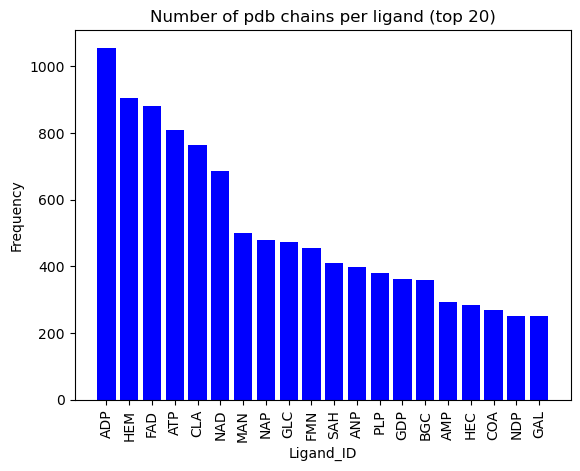

In [10]:
column_to_plot = "Ligand_ID"
value_counts = filtered_df[column_to_plot].value_counts()

n_ligands = 20
# Plot the histogram
plt.bar(value_counts.index[:n_ligands], value_counts.values[:n_ligands], color='blue')
plt.xticks(fontsize=10)  
last_bar_height = value_counts.values[:n_ligands][-1]


plt.xticks(rotation=90)

plt.xlabel(column_to_plot)
plt.ylabel('Frequency')
plt.title(f'Number of pdb chains per ligand (top {n_ligands})')

# Show plot
plt.show()

In [11]:
# print statistics
print(f"Total number of ligands: {len(filtered_df['Ligand_ID'].unique())}")
print(f"Total number of PDB IDs: {len(filtered_df['PDB ID'].unique())}")
print(f"Total number of receptor chains: {len(filtered_df['Receptor chain'].unique())}")
print(f"Total number of ligands with heavy atoms >= 10: {len(filtered_df[filtered_df['n_ligand_atoms'] >= 10]['Ligand_ID'].unique())}")
print(f"Total number of ligands with heavy atoms < 10: {len(filtered_df[filtered_df['n_ligand_atoms'] < 10]['Ligand_ID'].unique())}")
print(f"Total number of ligands with heavy atoms < 10:          {len(filtered_df[filtered_df['n_ligand_atoms'] < 10])}")

Total number of ligands: 1940
Total number of PDB IDs: 16574
Total number of receptor chains: 305
Total number of ligands with heavy atoms >= 10: 1940
Total number of ligands with heavy atoms < 10: 0
Total number of ligands with heavy atoms < 10:          0


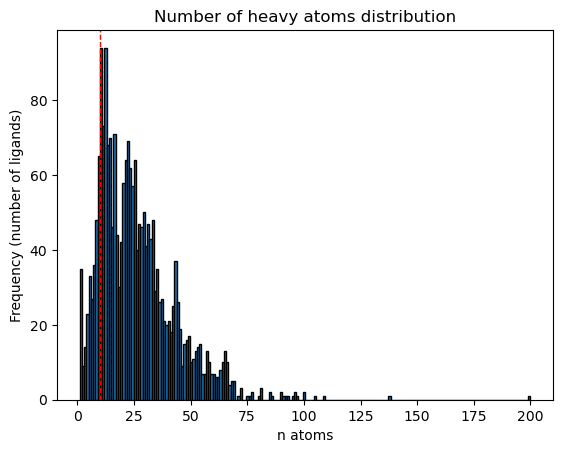

In [12]:

values = list(ligand_to_n_atoms.values())
plt.hist(values, bins=max(values), edgecolor='black')
plt.axvline(x=10, color='red', linestyle='--', linewidth=1, label='Value = 10')

plt.title('Number of heavy atoms distribution')
plt.xlabel('n atoms')
plt.ylabel('Frequency (number of ligands)')
plt.show()

## Calculate CATH degree

In [13]:
# cath_chains = pd.read_csv('/home/iscb/wolfson/hagairavid/databases/cath-domain-list.txt',sep='\s+', names=['pdb_chain', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k'], skiprows=16)
cath_chains = pd.read_csv('/home/iscb/wolfson/hagairavid/ligand_alligner/cath-classification-data/cath-domain-list.txt',sep='\s+', names=['pdb_chain', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k'], skiprows=16)
# cath_chains = cath_chains.set_index('pdb_chain')
cath_chains['domain'] = cath_chains['pdb_chain'].str[-2:]
cath_chains['chain'] = cath_chains['pdb_chain'].str[:-2]

In [14]:
def compare_rows(row1, row2):
    unequal_indices = np.where(row1 != row2)[0]
    if len(unequal_indices) == 0:
        return len(row1)
    else:
        return unequal_indices[0]

In [15]:
def compute_cath_degree(combinations, unique_pairs, result_rows, missing_chains):
    
    for row1, row2 in combinations:
        row1 = row1[1]
        row2 = row2[1]

        if row1['PDB ID'] != row2['PDB ID'] and (row1.iloc[0], row2.iloc[0]) not in unique_pairs and (row2.iloc[0], row1.iloc[0]) not in unique_pairs:
            unique_pairs.add((row1.iloc[0], row2.iloc[0]))
            chain1 = f"{row1['PDB ID']}{row1['Receptor chain']}"
            chain2 = f"{row2['PDB ID']}{row2['Receptor chain']}"

            if chain1 in missing_chains or chain2 in missing_chains:
                continue

            chain1_domains = cath_chains[cath_chains['chain'] == chain1]
            if chain1_domains.empty:
                missing_chains.add(chain1)
                continue

            chain2_domains = cath_chains[cath_chains['chain'] == chain2]
            if chain2_domains.empty:
                missing_chains.add(chain2)
                continue

            max_similarity = -1
            for _, domain1 in chain1_domains.iterrows():
                for _, domain2 in chain2_domains.iterrows():
                    max_similarity = max(max_similarity, compare_rows(domain1.values[1:9], domain2.values[1:9]))

            result_rows.append([row1['PDB ID'], row2['PDB ID'], row1['Receptor chain'], row2['Receptor chain'], row2['Ligand_ID'], max_similarity, heavy_atom_count])
            if len(result_rows) % 10000 == 0:
                print(len(result_rows))

In [16]:
all_combinations = []

for ligand_id, n_atoms in ligand_to_n_atoms.items():
    # print(f"Process ligand {ligand_id}, n atoms is  {n_atoms}")
    if n_atoms < 10:
        continue
    filtered_rows = filtered_df[filtered_df['Ligand_ID'] == ligand_id]
    # print(f"Process ligand {ligand_id}, n chains is  {filtered_rows.shape[0]}")
    new_combinations = list(itertools.combinations(filtered_rows.iterrows(), 2))
    if len(new_combinations) > 10000:
        new_combinations = random.sample(new_combinations, 10000)
    print(f"Processing ligand {ligand_id} with {len(new_combinations)} combinations")
    all_combinations += new_combinations
    # print(f"Processed {len(all_combinations)} combinations for ligand {ligand_id}")

result_rows = multiprocessing.Manager().list()  # Use Manager to create a shared list
missing_chains = set()  
unique_pairs = set() 
    
num_processes = multiprocessing.cpu_count()
chunk_size = max(len(all_combinations) // num_processes, 1)
chunks = [all_combinations[i:i + chunk_size] for i in range(0, len(all_combinations), chunk_size)]
with multiprocessing.Pool(processes=num_processes) as pool:
    pool.starmap(compute_cath_degree, [(chunk, unique_pairs, result_rows, missing_chains) for chunk in chunks])

result_df = pd.DataFrame(list(result_rows), columns=['ref_protein', 'mov_protein', 'ref_chain', 'mov_chain', 'ligand_id', 'CATH_degree', 'ligand_n_atoms'])
result_df.to_csv(os.path.join('calculated_cath', f'{result_df.shape[0]}_10_08_2025.csv'))

Processing ligand 017 with 36 combinations
Processing ligand 01K with 1 combinations
Processing ligand 07D with 10 combinations
Processing ligand 08I with 0 combinations
Processing ligand 0BJ with 1 combinations
Processing ligand 0ET with 0 combinations
Processing ligand 0FQ with 1 combinations
Processing ligand 0FV with 1 combinations
Processing ligand 0FX with 21 combinations
Processing ligand 0G6 with 36 combinations
Processing ligand 0GA with 1 combinations
Processing ligand 0GJ with 6 combinations
Processing ligand 0HK with 3 combinations
Processing ligand 0IE with 3 combinations
Processing ligand 0J1 with 1 combinations
Processing ligand 0JO with 1 combinations
Processing ligand 0K3 with 1 combinations
Processing ligand 0L1 with 1 combinations
Processing ligand 0LI with 3 combinations
Processing ligand 0MK with 1 combinations
Processing ligand 0MR with 0 combinations
Processing ligand 0O2 with 6 combinations
Processing ligand 0P6 with 0 combinations
Processing ligand 0SA with 0 c

In [ ]:
# take only pairs with CATH degree < 5
result_df = result_df[result_df['CATH_degree'] < 5]


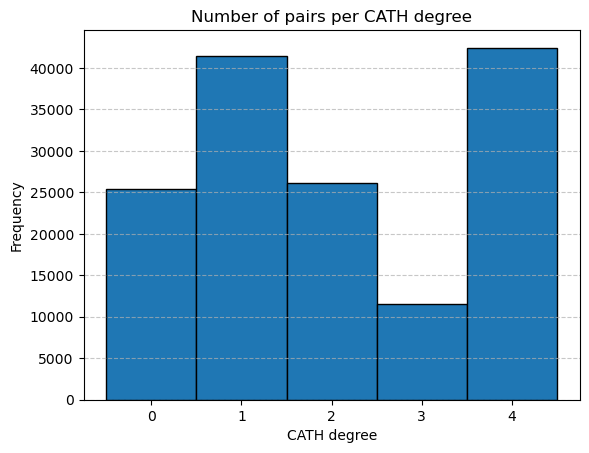

In [26]:
# plot histogram of number of pairs per CATH degree
plt.hist(result_df['CATH_degree'], bins=range(6), align='left', edgecolor='black')
plt.xlabel('CATH degree')
plt.ylabel('Frequency')
plt.title('Number of pairs per CATH degree')
plt.xticks(range(5))
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

In [24]:
# print statistics.

# n pairs
print(f"Total number of ligands: {len(result_df)}")

# n pairs per CATH degree
print(f"Total number of ligands with CATH degree 0: {len(result_df[result_df['CATH_degree'] == 0])}")
print(f"Total number of ligands with CATH degree 1: {len(result_df[result_df['CATH_degree'] == 1])}")
print(f"Total number of ligands with CATH degree 2: {len(result_df[result_df['CATH_degree'] == 2])}")
print(f"Total number of ligands with CATH degree 3: {len(result_df[result_df['CATH_degree'] == 3])}")
print(f"Total number of ligands with CATH degree 4: {len(result_df[result_df['CATH_degree'] == 4])}")
# print(f"


Total number of ligands: 146827
Total number of ligands with CATH degree 0: 25404
Total number of ligands with CATH degree 1: 41397
Total number of ligands with CATH degree 2: 26086
Total number of ligands with CATH degree 3: 11510
Total number of ligands with CATH degree 4: 42430


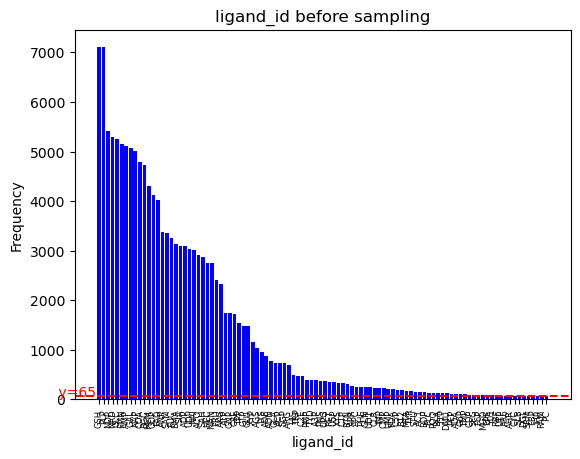

In [27]:
column_to_plot = "ligand_id"
value_counts = result_df[column_to_plot].value_counts()
plt.bar(value_counts.index[:100], value_counts.values[:100], color='blue')
plt.xticks(fontsize=6)  
last_bar_height = value_counts.values[:100][-1]
plt.axhline(y=last_bar_height, color='red', linestyle='--')
plt.text(-10, last_bar_height, f' y={last_bar_height}', color='red', fontsize=10)
plt.xticks(rotation=90)
plt.xlabel(column_to_plot)
plt.ylabel('Frequency')
plt.title(f'{column_to_plot} before sampling')
plt.show()

In [28]:
ligand_freq = result_df['ligand_id'].value_counts()
cath_degree_freq = result_df['CATH_degree'].value_counts()

def calculate_probability(row):
    ligand_prob = 1 / np.sqrt(ligand_freq[row['ligand_id']])
    cath_prob = 1 / np.sqrt(cath_degree_freq[row['CATH_degree']])
    return ligand_prob * cath_prob

result_df['Probability'] = result_df.apply(calculate_probability, axis=1)
result_df['Probability'] /= result_df['Probability'].sum()

print(result_df['Probability'])

2         0.000057
3         0.000009
5         0.000003
6         0.000057
7         0.000007
            ...   
149223    0.000006
149224    0.000006
149225    0.000006
149226    0.000005
149227    0.000006
Name: Probability, Length: 146827, dtype: float64


In [29]:
sampled_rows = np.random.choice(result_df.index, size=result_df.shape[0], replace=False, p=result_df['Probability'])
sampled_df = result_df.loc[sampled_rows]

In [ ]:
column_to_plot = "ligand_id"
value_counts = sampled_df[column_to_plot].value_counts()

# Plot the histogram
plt.bar(value_counts.index[:20], value_counts.values[:20], color='green' \
'')
plt.xticks(fontsize=10)  # Adjust the font size as per your preference
# Extract the height of the last bar
last_bar_height = value_counts.values[:20][-1]

# plt.axhline(y=last_bar_height, color='red', linestyle='--')
# plt.text(-10, last_bar_height, f' y={last_bar_height}', color='red', fontsize=10)
plt.xticks(rotation=90)
plt.xlabel(column_to_plot)
plt.ylabel('Frequency')
# plt.title(f'{column_to_plot} after sampling')
plt.title(f'Number of pairs per ligand id (top 20 ligands)')

# Show plot
plt.show()

NameError: name 'sampled_df' is not defined

In [31]:
sampled_df.shape

(146827, 8)

In [32]:
import datetime


sampled_df.head()
date = datetime.datetime.now().strftime("%d_%m")
sampled_df.to_csv(os.path.join('calculated_cath',f'sampled_{sampled_df.shape[0]}_{date}.csv'))